In [87]:
# imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pickle

from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder, label_binarize, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, Activation, Flatten,
                                      Conv2D, MaxPooling2D, BatchNormalization)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasClassifier

from PIL import Image


After dropping new_whale: 15697 images
Final whale classes: 20
Min images per class: 36
Max images per class: 73
Final class count: 20
Loading 974 images, grayscale, size 96x96...
  0/974 loaded
  500/974 loaded
Done.
X_cnn  shape: (974, 96, 96, 1)
X_flat shape: (974, 9216)


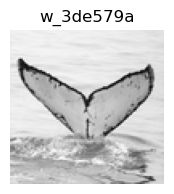

Class weights created for 20 classes.


In [89]:
# Load the label CSV
assert os.path.exists('train.csv'), "train.csv not found. Place train.csv in the same folder as this notebook."
df = pd.read_csv('train.csv')

# Clean-up

# Remove any duplicate rows
df.drop_duplicates(subset='Image', inplace=True)
df.reset_index(drop=True, inplace=True)

# drop "new_whale" because it is not a specific whale identity.
df = df[df['Id'] != 'new_whale'].copy()
df.reset_index(drop=True, inplace=True)

print("After dropping new_whale:", len(df), "images")

# Keep only common whale IDs with enough images.
TOP_N_CLASSES = 20
MIN_IMAGES_PER_CLASS = 20
MAX_IMAGES_PER_CLASS = None

counts = df['Id'].value_counts()

valid_ids = (
    counts[counts >= MIN_IMAGES_PER_CLASS]
    .head(TOP_N_CLASSES)
    .index
)

df = df[df['Id'].isin(valid_ids)].copy()
df.reset_index(drop=True, inplace=True)

print("Final whale classes:", df['Id'].nunique())
print("Min images per class:", df['Id'].value_counts().min())
print("Max images per class:", df['Id'].value_counts().max())

# Re-encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['Id'])
num_classes = df['label'].nunique()

print("Final class count:", num_classes)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Load / Greyscale
TARGET_SIZE = (96, 96)
TRAIN_DIR = 'train/'

N = len(df)
H, W = TARGET_SIZE
C = 1

print(f"Loading {N} images, grayscale, size {H}x{W}...")

# X_flat for SVM and ANN.
# X_cnn for CNN.
X_flat = np.zeros((N, H * W), dtype='float32')
X_cnn = np.zeros((N, H, W, C), dtype='float32')
y = df['label'].values

for i, fname in enumerate(df['Image']):
    path = os.path.join(TRAIN_DIR, fname)

    img = Image.open(path).convert('L')
    img = img.resize((W, H), Image.LANCZOS)
    arr = np.array(img, dtype='float32')

    X_cnn[i] = arr[:, :, np.newaxis]
    X_flat[i] = arr.flatten()

    if i % 500 == 0:
        print(f"  {i}/{N} loaded")

print("Done.")
print("X_cnn  shape:", X_cnn.shape)
print("X_flat shape:", X_flat.shape)

# Visualize a sample
plt.figure(figsize=(2, 2), dpi=100)
plt.imshow(X_cnn[0].squeeze(), cmap='gray')
plt.title(df['Id'].iloc[0])
plt.axis('off')
plt.show()

# Normalize image values to 0-1
X_cnn = X_cnn / 255.0
X_flat = X_flat / 255.0

idx = np.arange(len(y))

train_idx, val_idx = train_test_split(
    idx,
    test_size=0.20,
    random_state=5,
    stratify=y
)

# Flat arrays for SVM/ANN
flat_scaler = StandardScaler()
X_train_flat = flat_scaler.fit_transform(X_flat[train_idx])
X_val_flat = flat_scaler.transform(X_flat[val_idx])

y_train = y[train_idx]
y_val = y[val_idx]

# CNN arrays
X_train_cnn = X_cnn[train_idx]
X_val_cnn = X_cnn[val_idx]

# One-hot labels for Keras CNN
y_train_oh = to_categorical(y_train, num_classes)
y_val_oh = to_categorical(y_val, num_classes)

# Handle imbalance
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, weights))

print("Class weights created for", len(class_weight_dict), "classes.")

Training:   779 images
Validation: 195 images
Classes:    20
Variance explained by 300 components: 95.5%


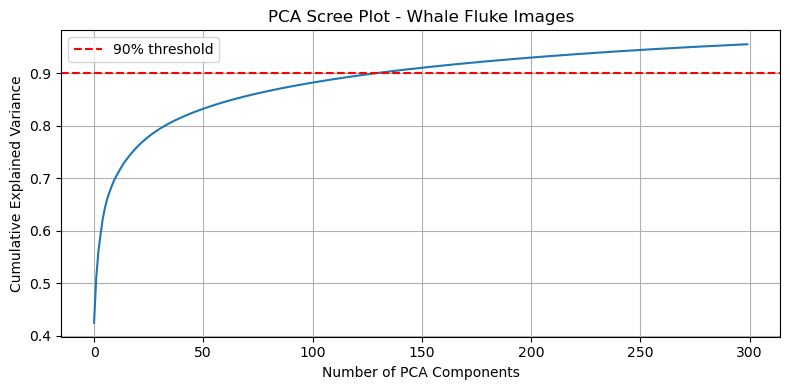

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters: {'C': 10, 'gamma': 0.001}
Best CV Accuracy: 0.21441441441441444
SVM Accuracy: 0.24615384615384617
SVM Macro AUC: 0.7275235390264909


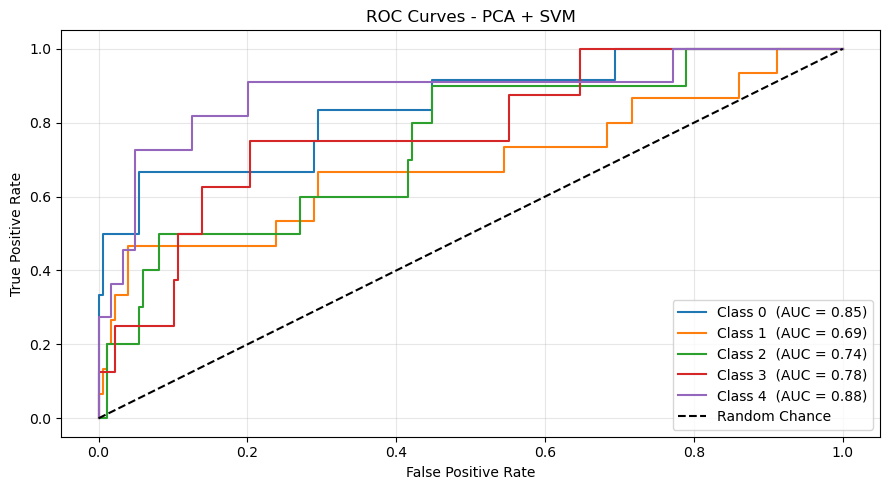

In [90]:
# Approach 01: PCA + SVM

X_tr_svm = X_train_flat
X_te_svm = X_val_flat
y_tr_svm = y_train
y_te_svm = y_val

print(f"Training:   {X_tr_svm.shape[0]} images")
print(f"Validation: {X_te_svm.shape[0]} images")
print(f"Classes:    {num_classes}")

k = min(300, X_tr_svm.shape[0] - 1, X_tr_svm.shape[1])

my_pca = PCA(n_components=k, whiten=True, random_state=5)

X_train_pca = my_pca.fit_transform(X_tr_svm)
X_test_pca = my_pca.transform(X_te_svm)

explained = np.cumsum(my_pca.explained_variance_ratio_)
print(f"Variance explained by {k} components: {explained[-1] * 100:.1f}%")

# Plot PCA explained variance
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(my_pca.explained_variance_ratio_))
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot - Whale Fluke Images')
plt.axhline(0.90, color='r', linestyle='--', label='90% threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# SVM with Grid Search
param_grid = {
    'C': [1, 10, 100, 1000],
    'gamma': ['scale', 0.01, 0.001, 0.0001]
}

svm_model = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=1
)

svm_cv_splits = min(3, int(pd.Series(y_tr_svm).value_counts().min()))

if svm_cv_splits < 2:
    raise ValueError("SVM grid search needs at least 2 training examples in every class.")

cv_svm = StratifiedKFold(
    n_splits=svm_cv_splits,
    shuffle=True,
    random_state=5
)

grid_svm = GridSearchCV(
    svm_model,
    param_grid,
    cv=cv_svm,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

grid_svm.fit(X_train_pca, y_tr_svm)

print("Best parameters:", grid_svm.best_params_)
print("Best CV Accuracy:", grid_svm.best_score_)

best_svm = grid_svm.best_estimator_

# Predictions
y_pred_svm = best_svm.predict(X_test_pca)

# Evaluation

# Accuracy
acc_svm = accuracy_score(y_te_svm, y_pred_svm)
print("SVM Accuracy:", acc_svm)

# ROC + AUC
y_prob_svm = best_svm.predict_proba(X_test_pca)

svm_classes = best_svm.classes_
svm_class_to_col = {
    class_label: col
    for col, class_label in enumerate(svm_classes)
}

# Only evaluate classes that appear in both validation labels and the trained SVM.
svm_classes_present = np.intersect1d(np.unique(y_te_svm), svm_classes)

svm_prob_cols = [
    svm_class_to_col[class_label]
    for class_label in svm_classes_present
]

y_te_bin = label_binarize(
    y_te_svm,
    classes=svm_classes_present
)

auc_svm = roc_auc_score(
    y_te_bin,
    y_prob_svm[:, svm_prob_cols],
    average='macro'
)

print("SVM Macro AUC:", auc_svm)

# Plot ROC curves for first 5 classes
plt.figure(figsize=(9, 5))

for idx, class_label in enumerate(svm_classes_present[:5]):
    prob_col = svm_class_to_col[class_label]

    fpr, tpr, _ = roc_curve(
        y_te_bin[:, idx],
        y_prob_svm[:, prob_col]
    )

    auc_i = roc_auc_score(
        y_te_bin[:, idx],
        y_prob_svm[:, prob_col]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"Class {class_label}  (AUC = {auc_i:.2f})"
    )

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - PCA + SVM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Fitting 2 folds for each of 4 candidates, totalling 8 fits


C:\Users\jliu161\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\jliu161\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\jliu161\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(

Best score (accuracy): 0.2246490013842199
Best parameters:       {'batch_size': 32, 'epochs': 50}
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2667 - loss: 8.4392 
The accuracy is:  0.2666666805744171
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
ANN Accuracy: 0.26666666666666666
ANN Macro AUC: 0.7360816372224808


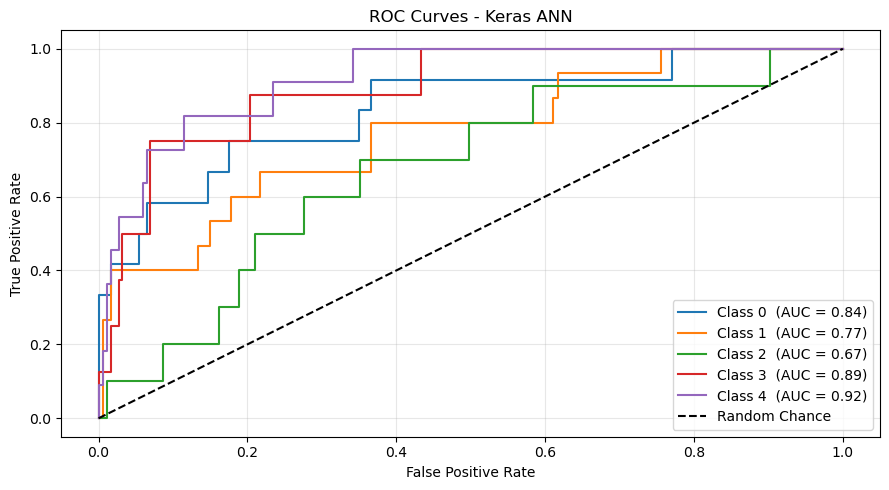

In [91]:
# Approach 02: Keras ANN with GridSearchCV

def model_creator():

    model = Sequential()
    input_size = H * W * C
    hidden_neurons = 512
    out_size = num_classes  # num of unique whale IDs

    # Hidden layer 1
    model.add(Dense(hidden_neurons, input_dim=input_size))
    model.add(Activation('relu'))

    # Hidden layer 2
    model.add(Dense(128))
    model.add(Activation('relu'))

    # Output layer
    model.add(Dense(out_size))
    model.add(Activation('softmax'))

    # Compile
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])
    return model

# GridSearchCV

seed = 2
np.random.seed(seed)
tf.random.set_seed(seed)

ann_model = KerasClassifier(model=model_creator, verbose=0)

param_grid_ann = {
    'batch_size': [16, 32],
    'epochs':     [30, 50]
}

ann_cv_splits = min(2, int(pd.Series(y_train).value_counts().min()))
if ann_cv_splits < 2:
    raise ValueError("ANN grid search needs at least 2 training examples in every class.")
cv_ann = StratifiedKFold(n_splits=ann_cv_splits, shuffle=True, random_state=seed)

grid_ann = GridSearchCV(
    estimator=ann_model,
    param_grid=param_grid_ann,
    scoring='accuracy',
    cv=cv_ann,
    verbose=1,
    n_jobs=1
)

grid_ann_result = grid_ann.fit(X_train_flat, y_train)

print("Best score (accuracy):", grid_ann_result.best_score_)
print("Best parameters:      ", grid_ann_result.best_params_)

# Get Best Model
best_ann = grid_ann.best_estimator_.model_

score_ann = best_ann.evaluate(X_val_flat, y_val, verbose=1)
print('The accuracy is: ', score_ann[1])

y_prob_ann = best_ann.predict(X_val_flat)
y_pred_ann = np.argmax(y_prob_ann, axis=1)

acc_ann = accuracy_score(y_val, y_pred_ann)
print("ANN Accuracy:", acc_ann)

# Evaluation

# AUC
val_classes_present = np.unique(y_val)
y_val_bin = label_binarize(y_val, classes=val_classes_present)

auc_ann = roc_auc_score(y_val_bin, y_prob_ann[:, val_classes_present], average='macro')
print("ANN Macro AUC:", auc_ann)

# ROC curves for first 5 validation classes
plt.figure(figsize=(9, 5))
for idx, class_label in enumerate(val_classes_present[:5]):
    fpr, tpr, _ = roc_curve(y_val_bin[:, idx], y_prob_ann[:, class_label])
    auc_i       = roc_auc_score(y_val_bin[:, idx], y_prob_ann[:, class_label])
    plt.plot(fpr, tpr, label=f"Class {class_label}  (AUC = {auc_i:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Keras ANN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [92]:
# Approach 03: CNN

# Build Model
def build_cnn(input_shape=(64, 64, 1), n_classes=500):

    model = Sequential()

    # Block 1
    model.add(Conv2D(32, (3, 3), padding='same', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Block 2
    model.add(Conv2D(64, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Block 3
    model.add(Conv2D(128, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.25))

    # Block 4
    model.add(Conv2D(256, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(0.4))

    model.add(Flatten())
    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dropout(0.5))
    model.add(Dense(n_classes, activation='softmax'))

    return model

cnn_model = build_cnn(input_shape=(H, W, C), n_classes=num_classes)

# Compile
cnn_model.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss = 'categorical_crossentropy',
    metrics = ['accuracy']
)

cnn_model.summary()

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-6, verbose=1)
]

# Train CNN
history_cnn = cnn_model.fit(X_train_cnn, y_train_oh, validation_data=(X_val_cnn, y_val_oh), batch_size=16, epochs=80, class_weight=class_weight_dict, 
                            callbacks=callbacks, verbose=1)

C:\Users\jliu161\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)                   │ (None, 96, 96, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_35               │ (None, 96, 96, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_134 (Activation)          │ (None, 96, 96, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_28 (MaxPooling2D)      │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_35 (Dropout)                 │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_29 (Conv2D)                   │ (None, 48, 48, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_36               │ (None, 48, 48, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_135 (Activation)          │ (None, 48, 48, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_29 (MaxPooling2D)      │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_36 (Dropout)                 │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_30 (Conv2D)                   │ (None, 24, 24, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_37               │ (None, 24, 24, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_136 (Activation)          │ (None, 24, 24, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_30 (MaxPooling2D)      │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_37 (Dropout)                 │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_31 (Conv2D)                   │ (None, 12, 12, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_38               │ (None, 12, 12, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_137 (Activation)          │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_31 (MaxPooling2D)      │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 5,121,172 (19.54 MB)

 Trainable params: 5,119,188 (19.53 MB)

 Non-trainable params: 1,984 (7.75 KB)

Epoch 1/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 20s 240ms/step - accuracy: 0.1130 - loss: 3.4754 - val_accuracy: 0.0462 - val_loss: 3.2214 - learning_rate: 0.0010
Epoch 2/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 226ms/step - accuracy: 0.2478 - loss: 2.6068 - val_accuracy: 0.0410 - val_loss: 3.3698 - learning_rate: 0.0010
Epoch 3/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 215ms/step - accuracy: 0.2927 - loss: 2.2999 - val_accuracy: 0.0564 - val_loss: 3.5599 - learning_rate: 0.0010
Epoch 4/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 214ms/step - accuracy: 0.4300 - loss: 1.9237 - val_accuracy: 0.0462 - val_loss: 3.5900 - learning_rate: 0.0010
Epoch 5/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.5021 - loss: 1.6141
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 219ms/step - accuracy: 0.4994 - loss: 1.5591 - val_accuracy: 0.0564 - val_loss: 3.6823 - learning_rate: 0.0010
Epoch 6/80
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 216ms/step - accuracy: 0.6200 - loss: 1.20

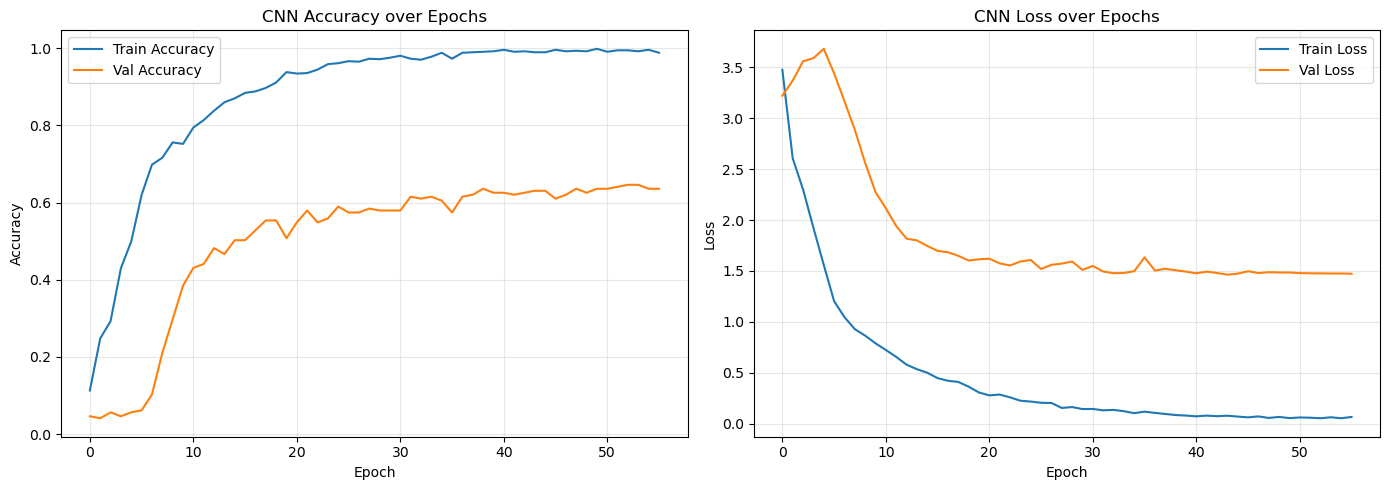

In [93]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_cnn.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history_cnn.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('CNN Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cnn.history['loss'],     label='Train Loss')
axes[1].plot(history_cnn.history['val_loss'], label='Val Loss')
axes[1].set_title('CNN Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step
CNN Accuracy: 0.6307692307692307
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.6308 - loss: 1.4630
The accuracy is:  0.6307692527770996
CNN Macro AUC: 0.9391918271133857


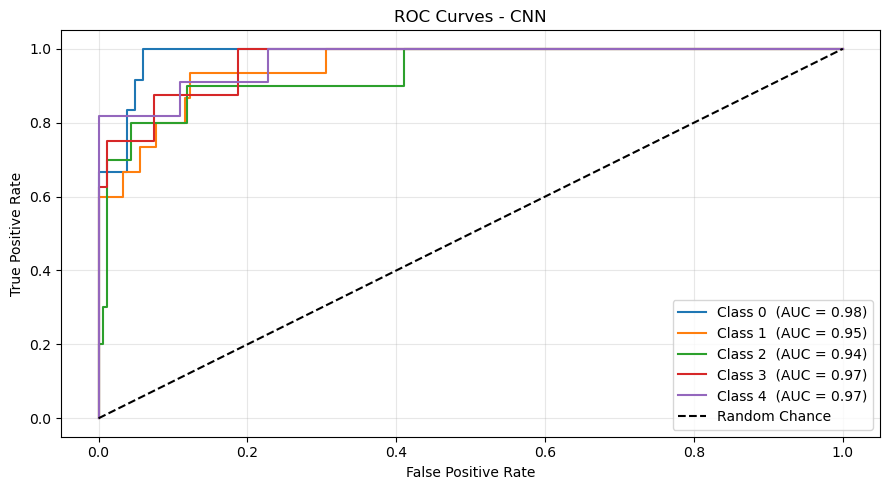

In [94]:
# Evaluation

# Predict
y_prob_cnn = cnn_model.predict(X_val_cnn)
y_pred_cnn = np.argmax(y_prob_cnn, axis=1)

# Accuracy
acc_cnn = accuracy_score(y_val, y_pred_cnn)
print("CNN Accuracy:", acc_cnn)

score_cnn = cnn_model.evaluate(X_val_cnn, y_val_oh, verbose=1)
print("The accuracy is: ", score_cnn[1])

# AUC
val_classes_present = np.unique(y_val)
y_val_bin = label_binarize(y_val, classes=val_classes_present)

auc_cnn = roc_auc_score(y_val_bin, y_prob_cnn[:, val_classes_present], average='macro')
print("CNN Macro AUC:", auc_cnn)

# ROC curves
plt.figure(figsize=(9, 5))
for idx, class_label in enumerate(val_classes_present[:5]):
    fpr, tpr, _ = roc_curve(y_val_bin[:, idx], y_prob_cnn[:, class_label])
    auc_i = roc_auc_score(y_val_bin[:, idx], y_prob_cnn[:, class_label])
    plt.plot(fpr, tpr, label=f"Class {class_label}  (AUC = {auc_i:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - CNN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


    Model  Accuracy  Macro AUC                        Input Format Training Speed
PCA + SVM  0.246154   0.727524 Flat / 255 + train-only scale + PCA           Fast
Keras ANN  0.266667   0.736082       Flat / 255 + train-only scale         Medium
      CNN  0.630769   0.939192                       (H,W,C) / 255 Slow (use GPU)


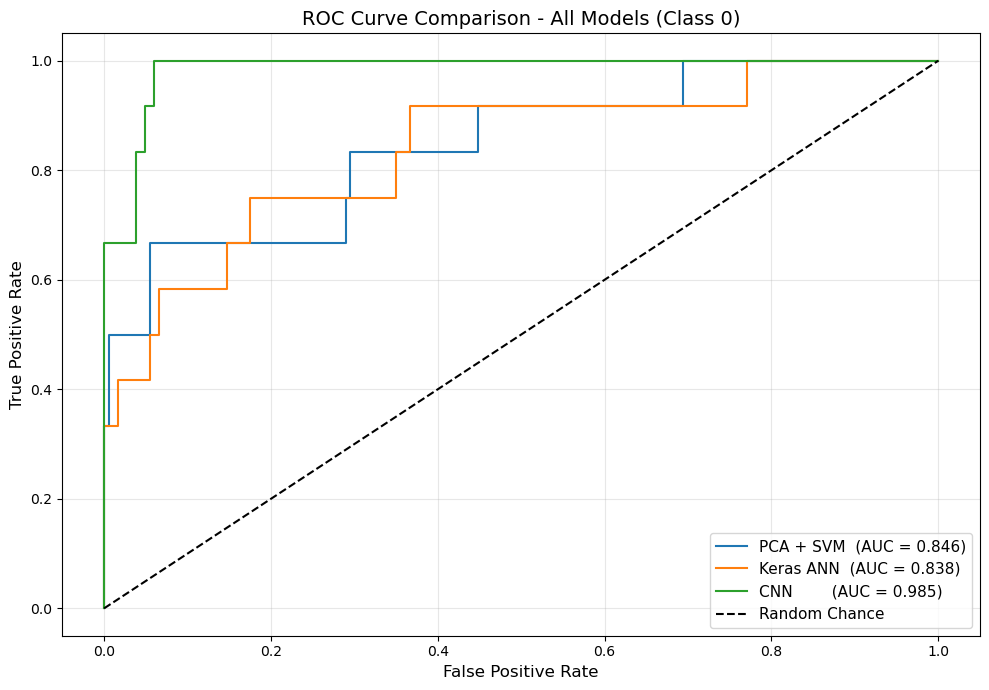

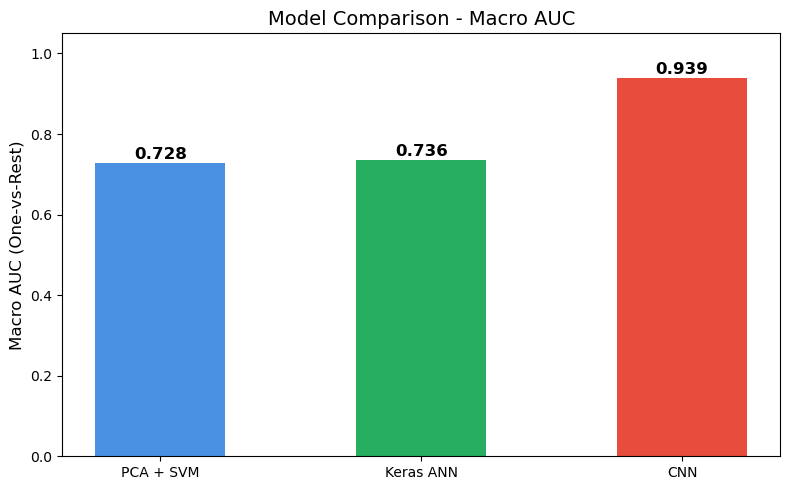

In [95]:
# Summary
results = {
    'Model':          ['PCA + SVM',   'Keras ANN',  'CNN'],
    'Accuracy':       [acc_svm,        acc_ann,       acc_cnn],
    'Macro AUC':      [auc_svm,        auc_ann,       auc_cnn],
    'Input Format':   ['Flat / 255 + train-only scale + PCA',
                       'Flat / 255 + train-only scale',
                       '(H,W,C) / 255'],
    'Training Speed': ['Fast',         'Medium',      'Slow (use GPU)'],
}
summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

# Find a class that appears in ALL three val/test sets
shared_class = np.intersect1d(svm_classes_present, val_classes_present)[0]

# Get column positions for that class in each probability matrix
svm_bin_col = np.where(svm_classes_present == shared_class)[0][0]
svm_prob_col = svm_class_to_col[shared_class]
val_col = np.where(val_classes_present == shared_class)[0][0]

plt.figure(figsize=(10, 7))

# SVM
fpr, tpr, _ = roc_curve(y_te_bin[:, svm_bin_col], y_prob_svm[:, svm_prob_col])
auc_i = roc_auc_score(y_te_bin[:, svm_bin_col], y_prob_svm[:, svm_prob_col])
plt.plot(fpr, tpr, label=f'PCA + SVM  (AUC = {auc_i:.3f})')

# ANN
fpr, tpr, _ = roc_curve(y_val_bin[:, val_col], y_prob_ann[:, shared_class])
auc_i = roc_auc_score(y_val_bin[:, val_col], y_prob_ann[:, shared_class])
plt.plot(fpr, tpr, label=f'Keras ANN  (AUC = {auc_i:.3f})')

# CNN
fpr, tpr, _ = roc_curve(y_val_bin[:, val_col], y_prob_cnn[:, shared_class])
auc_i = roc_auc_score(y_val_bin[:, val_col], y_prob_cnn[:, shared_class])
plt.plot(fpr, tpr, label=f'CNN        (AUC = {auc_i:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title(f'ROC Curve Comparison - All Models (Class {shared_class})', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_comparison.png', dpi=150)
plt.show()

# Bar Chart
models = ['PCA + SVM', 'Keras ANN', 'CNN']
aucs   = [auc_svm,     auc_ann,     auc_cnn]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, aucs, color=['#4a90e2', '#27ae60', '#e74c3c'], width=0.5)
plt.ylim(0, 1.05)
plt.ylabel('Macro AUC (One-vs-Rest)', fontsize=12)
plt.title('Model Comparison - Macro AUC', fontsize=14)

for bar, val in zip(bars, aucs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('auc_comparison.png', dpi=150)
plt.show()
